# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [69]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [70]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [71]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

In [72]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

In [73]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [74]:
#### File management
# TO UPDATE
nb_id = "Zipf_Six_Modern"
odysseys = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [75]:
# Daframe with all the odysseys
dfs = []

for odyssey in odysseys:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df = df[['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
df["diff"] = df["num_words"] - df["num_tokens"]
e.check_df(df)

No missing values

df columns: Index(['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens', 'diff'], dtype='object') 

Shape: (144, 7)


In [76]:
df.sample(4, random_state=4)

,author,book_num,text,tokens,num_words,num_tokens,diff
128,Green,9,"[Then resourceful Odysseus responded to him, saying:\n, “Alkinoos, lord, most distinguished among all peoples,\n, it is indeed a good thing to listen to such a minstrel\n, as this man is, who rese...","[resourceful, odysseus, responded, saying, alkinoos, lord, distinguished, among, peoples, indeed, good, thing, listen, minstrel, man, resembles, gods, singing, say, greater, fulfillment, pleasure,...",5950,2786,3164
5,AT_Murray,6,"[So here Odysseus slept, overcome by sleep and\n, toil; but Athena went off to the demos and city of\n, the Phaeacians - a people who used to live in the fair town of Hypereia, near\n, the lawless...","[odysseus, slept, overcome, sleep, toil, athena, went, demos, city, phaeacians, people, used, live, fair, town, hypereia, near, lawless, cyclopes, cyclopes, stronger, force, plundered, king, nausi...",3470,1492,1978
61,Lattimore,14,"[But Odysseus himself left the harbor and ascended a rugged\n, path, through wooded country along the heights, where Athene\n, had indicated the noble swineherd, who beyond others\n, cared for the...","[odysseus, left, harbor, ascended, rugged, path, wooded, country, along, heights, athene, indicated, noble, swineherd, beyond, others, cared, house, properties, acquired, noble, odysseus, found, s...",6328,2728,3600
29,Fitzgerald,6,"[Far gone in weariness, in oblivion, \n, the noble and enduring man slept on; \n, but Athena in the night went down the land \n, of the Phaiakians, entering their city. \n, In days gone by, these ...","[far, gone, weariness, oblivion, noble, enduring, man, slept, athena, night, went, land, phaiakians, entering, city, days, gone, men, held, hypereia, country, wide, dancing, grounds, near, overbea...",2907,1454,1453


In [77]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   author      144 non-null    object
 1   book_num    144 non-null    int64 
 2   text        144 non-null    object
 3   tokens      144 non-null    object
 4   num_words   144 non-null    int64 
 5   num_tokens  144 non-null    int64 
 6   diff        144 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 3.3 MB


In [78]:

sys.getsizeof(df) / 1_000_000 # Size in MB

3.500748

In [79]:
print("Memory per column:", df.memory_usage(deep=True) / 1_000_000) # Size in MB
print("Total memory:", df.memory_usage(deep=True).sum() / 1_000_000) # Size in MB

Memory per column: Index        0.00
author       0.01
book_num     0.00
text         0.63
tokens       2.86
num_words    0.00
num_tokens   0.00
diff         0.00
dtype: float64
Total memory: 3.500716


#### 2. **The translators**

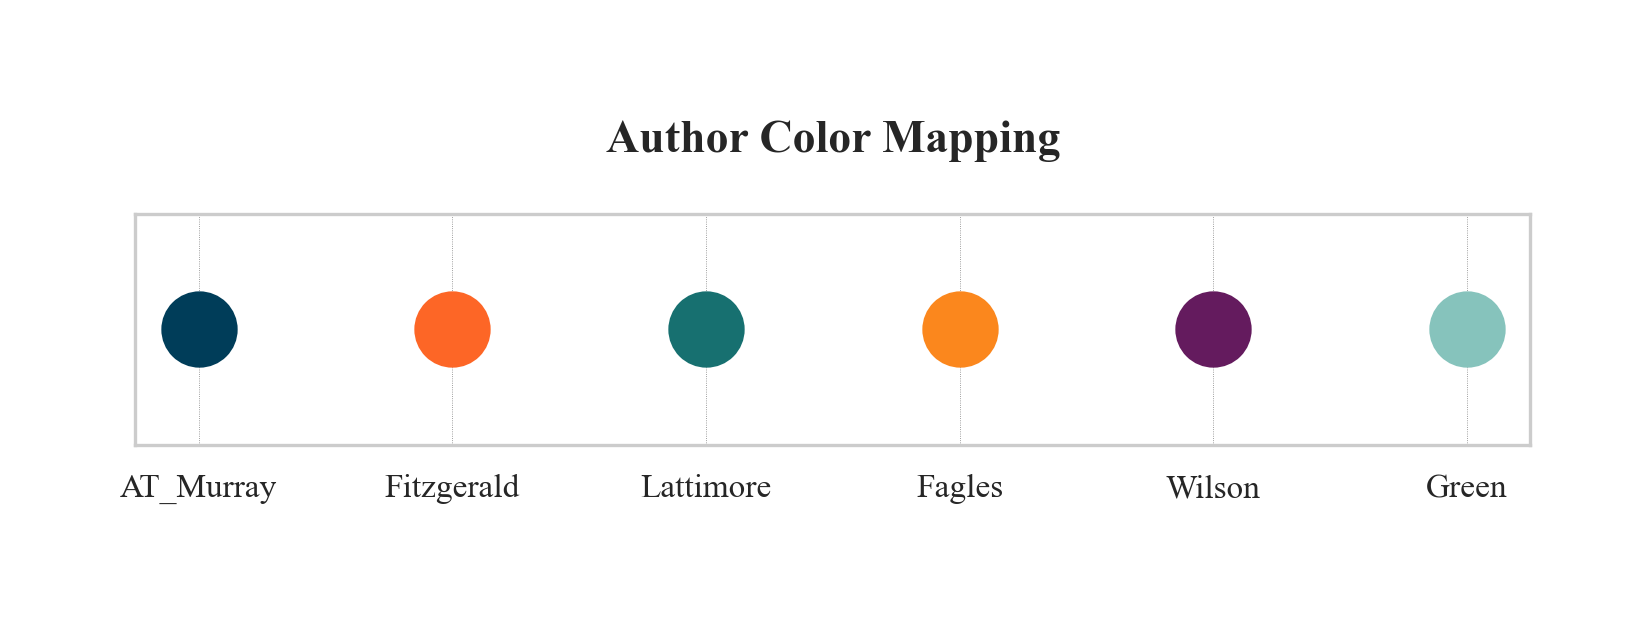

In [80]:
# Create a color mapping for authors
authors = df["author"].unique()
palette = {author: color for author, 
           color in zip(authors, viz.color_palette.values())}

# Plot the color mapping
plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=300)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Zipf’s Law Analysis**

### **What and why:** 

Zipf’s Law states that in a large text corpus, the frequency of a word is inversely proportional to its rank in the frequency table. This metric is relevant in comparing translations because it reveals how each translator balances **common vs. rare words**, shedding light on **lexical richness and stylistic choices**. This experiment provides empirical insight into whether a translator’s lexical distribution align with universal linguistic principles.


### **Implications for Translation Studies**

a) **natural linguistic flow:** Strong Zipfian adherence suggests that translators maintain natural language patterns, balancing high-frequency function words with low-frequency content words.  

b) **Poetic stylization:** Deviations may indicate differences in lexical richness, syntactic choices, or stylistic adaptation in translation.
    b) **Philological fidelity:** 'Stylistic' shifts from a natural distribution can also point out a cultural bias or genre requirements that, for epic oral poetry, demand disticnt repetitive and formulaic patterns, epithets, etc.



🔬 **Implementation**

To examine if the translation sample adhere to Zipf’s Law, I'll analyze the relationship between word frequency and rank:

1️⃣ Compute word frequencies for each translation.  
2️⃣ Rank words from most to least frequent.  
3️⃣ Plot word frequency vs. rank on a log-log scale.  

**Zipf’s Law in Translation**

Zipf’s Law states that in any natural language corpus, *the frequency of a word is inversely proportional to its rank:*


$$ f \propto \frac{1}{r} $$

Where:
* f = frequency of the word
* r = rank of the word (1st most frequent, 2nd most frequent, etc.)



In [81]:
# List of authors
authors = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Step 1: Flatten tokens and count word frequencies for each author
freq_dict = {
    author: Counter(
        token for tokens in df[df["author"] == author]["tokens"] for token in tokens
    )
    for author in authors
}

# Step 2: Convert word frequencies into sorted DataFrames with rank
df_zipf_dict = {
    author: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for author, freq in freq_dict.items()
}

# Example: Accessing a specific author’s Zipf DataFrame
df_zipf_dict["AT_Murray"].tail(15).T  # View the top-ranked words for AT_Murray

,3890,3891,3892,3893,3895,3897,3898,3903,3904,3905,3906,3907,3909,3910,6320
word,depends,noiselessly,threes,withies,ensconced,udders,backs,wont,mob,flowery,mead,bubbling,lag,nogood,parties
frequency,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
rank,6307.00,6308.00,6309.00,6310.00,6311.00,6312.00,6313.00,6314.00,6315.00,6316.00,6317.00,6318.00,6319.00,6320.00,6321.00


In [82]:
# Print total number of tokens per translator
for translator in translators:
    total_tokens = sum(freq_dict[translator].values())
    print(f"{translator}: {total_tokens} tokens")

AT_Murray: 51047 tokens
Fitzgerald: 53418 tokens
Lattimore: 61716 tokens
Fagles: 61974 tokens
Wilson: 47705 tokens
Green: 59202 tokens


In [83]:
# Compute min and max ranks across all translators
min_rank = min(df["rank"].min() for df in df_zipf_dict.values())
max_rank = max(df["rank"].max() for df in df_zipf_dict.values())

# Compute min and max frequencies across all translators
min_freq = min(df["frequency"].min() for df in df_zipf_dict.values())
max_freq = max(df["frequency"].max() for df in df_zipf_dict.values())

print(f"Rank range: from the {min_rank}st to {max_rank}th less freq word (unique set and stopwords removed).")
print(f"Frequency range: low words in rank appear at least {min_freq} time and the most freq has {max_freq} instances.")

Rank range: from the 1.0st to 8540.0th less freq word (unique set and stopwords removed).
Frequency range: low words in rank appear at least 1 time and the most freq has 718 instances.


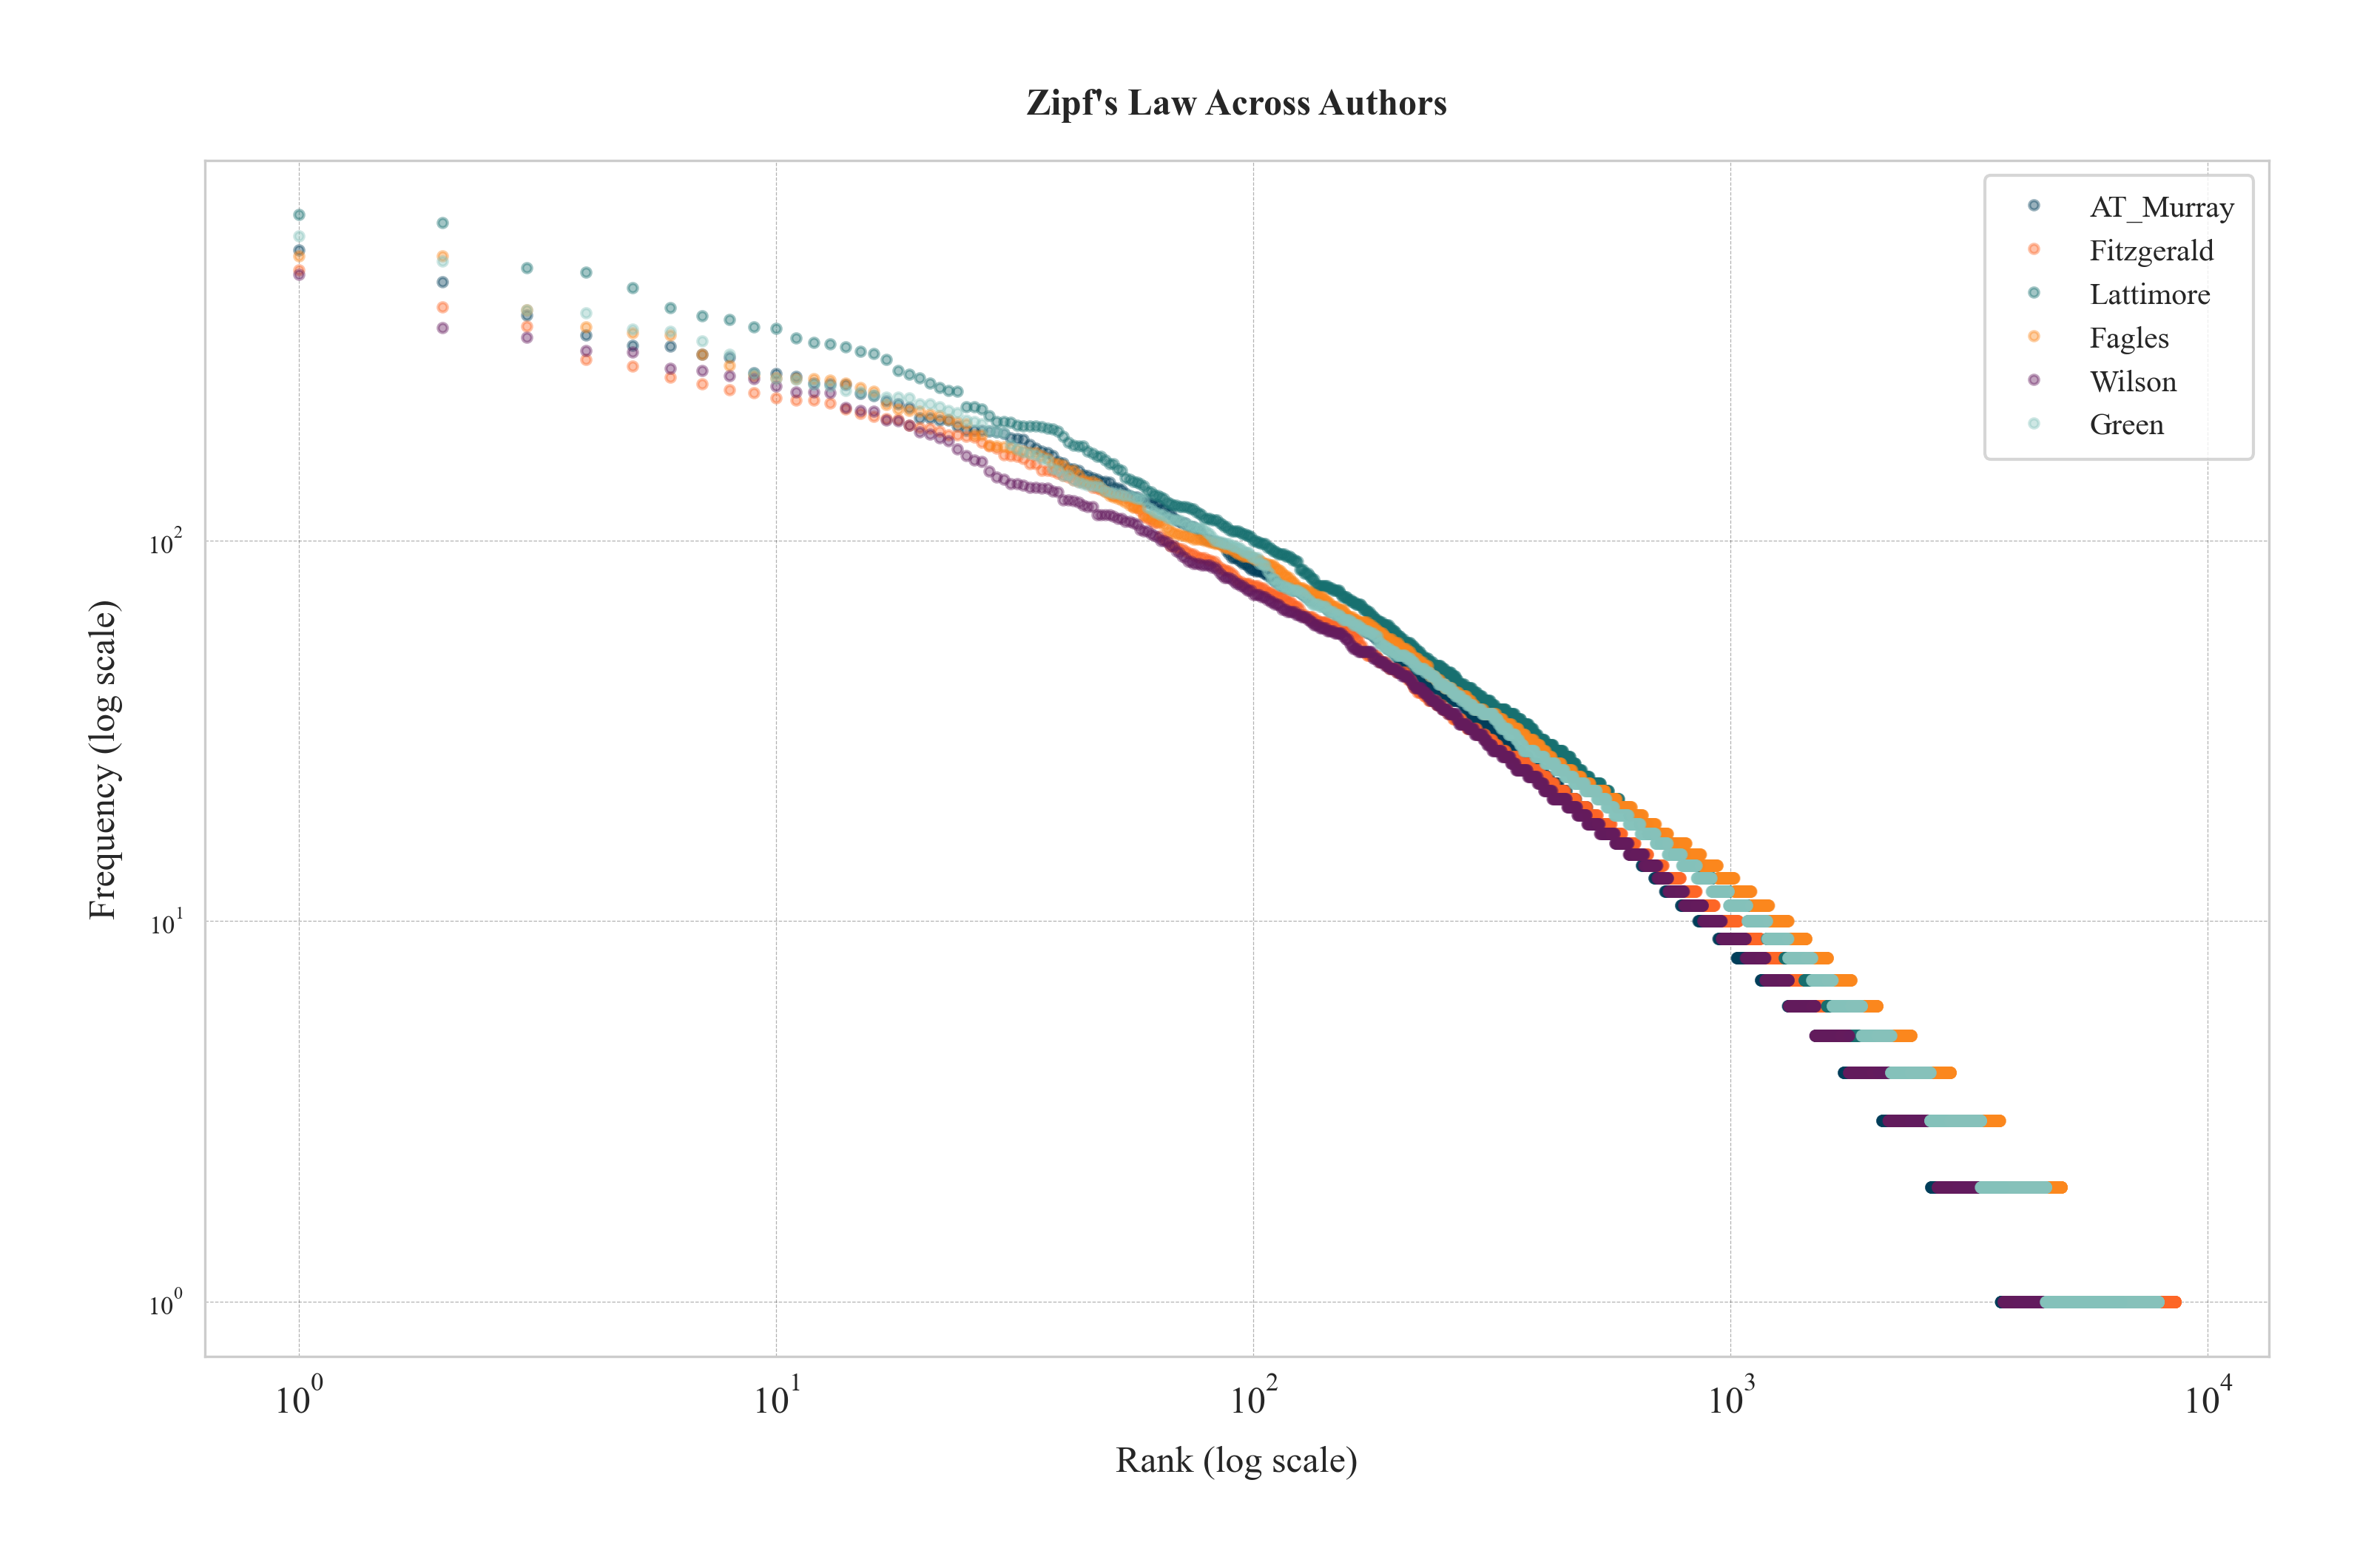

In [97]:
# Step 3: Zipf's Law Plot
# Using list of authors and freq_dict above
# Get unique authors dynamically
authors = df["author"].unique()

# Step 2: Convert to DataFrames with rank
df_zipf_dict = {
    author: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for author, freq in freq_dict.items()
}

# Step 3: Zipf's Law Plot
def plot_zipfs_law(df_zipf_dict):

    for author, df_zipf in df_zipf_dict.items():
        plt.loglog(df_zipf["rank"], df_zipf["frequency"], label=author, marker=".", linestyle="None", alpha=0.4)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across Authors")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

# Call the plotting function
plot_zipfs_law(df_zipf_dict)

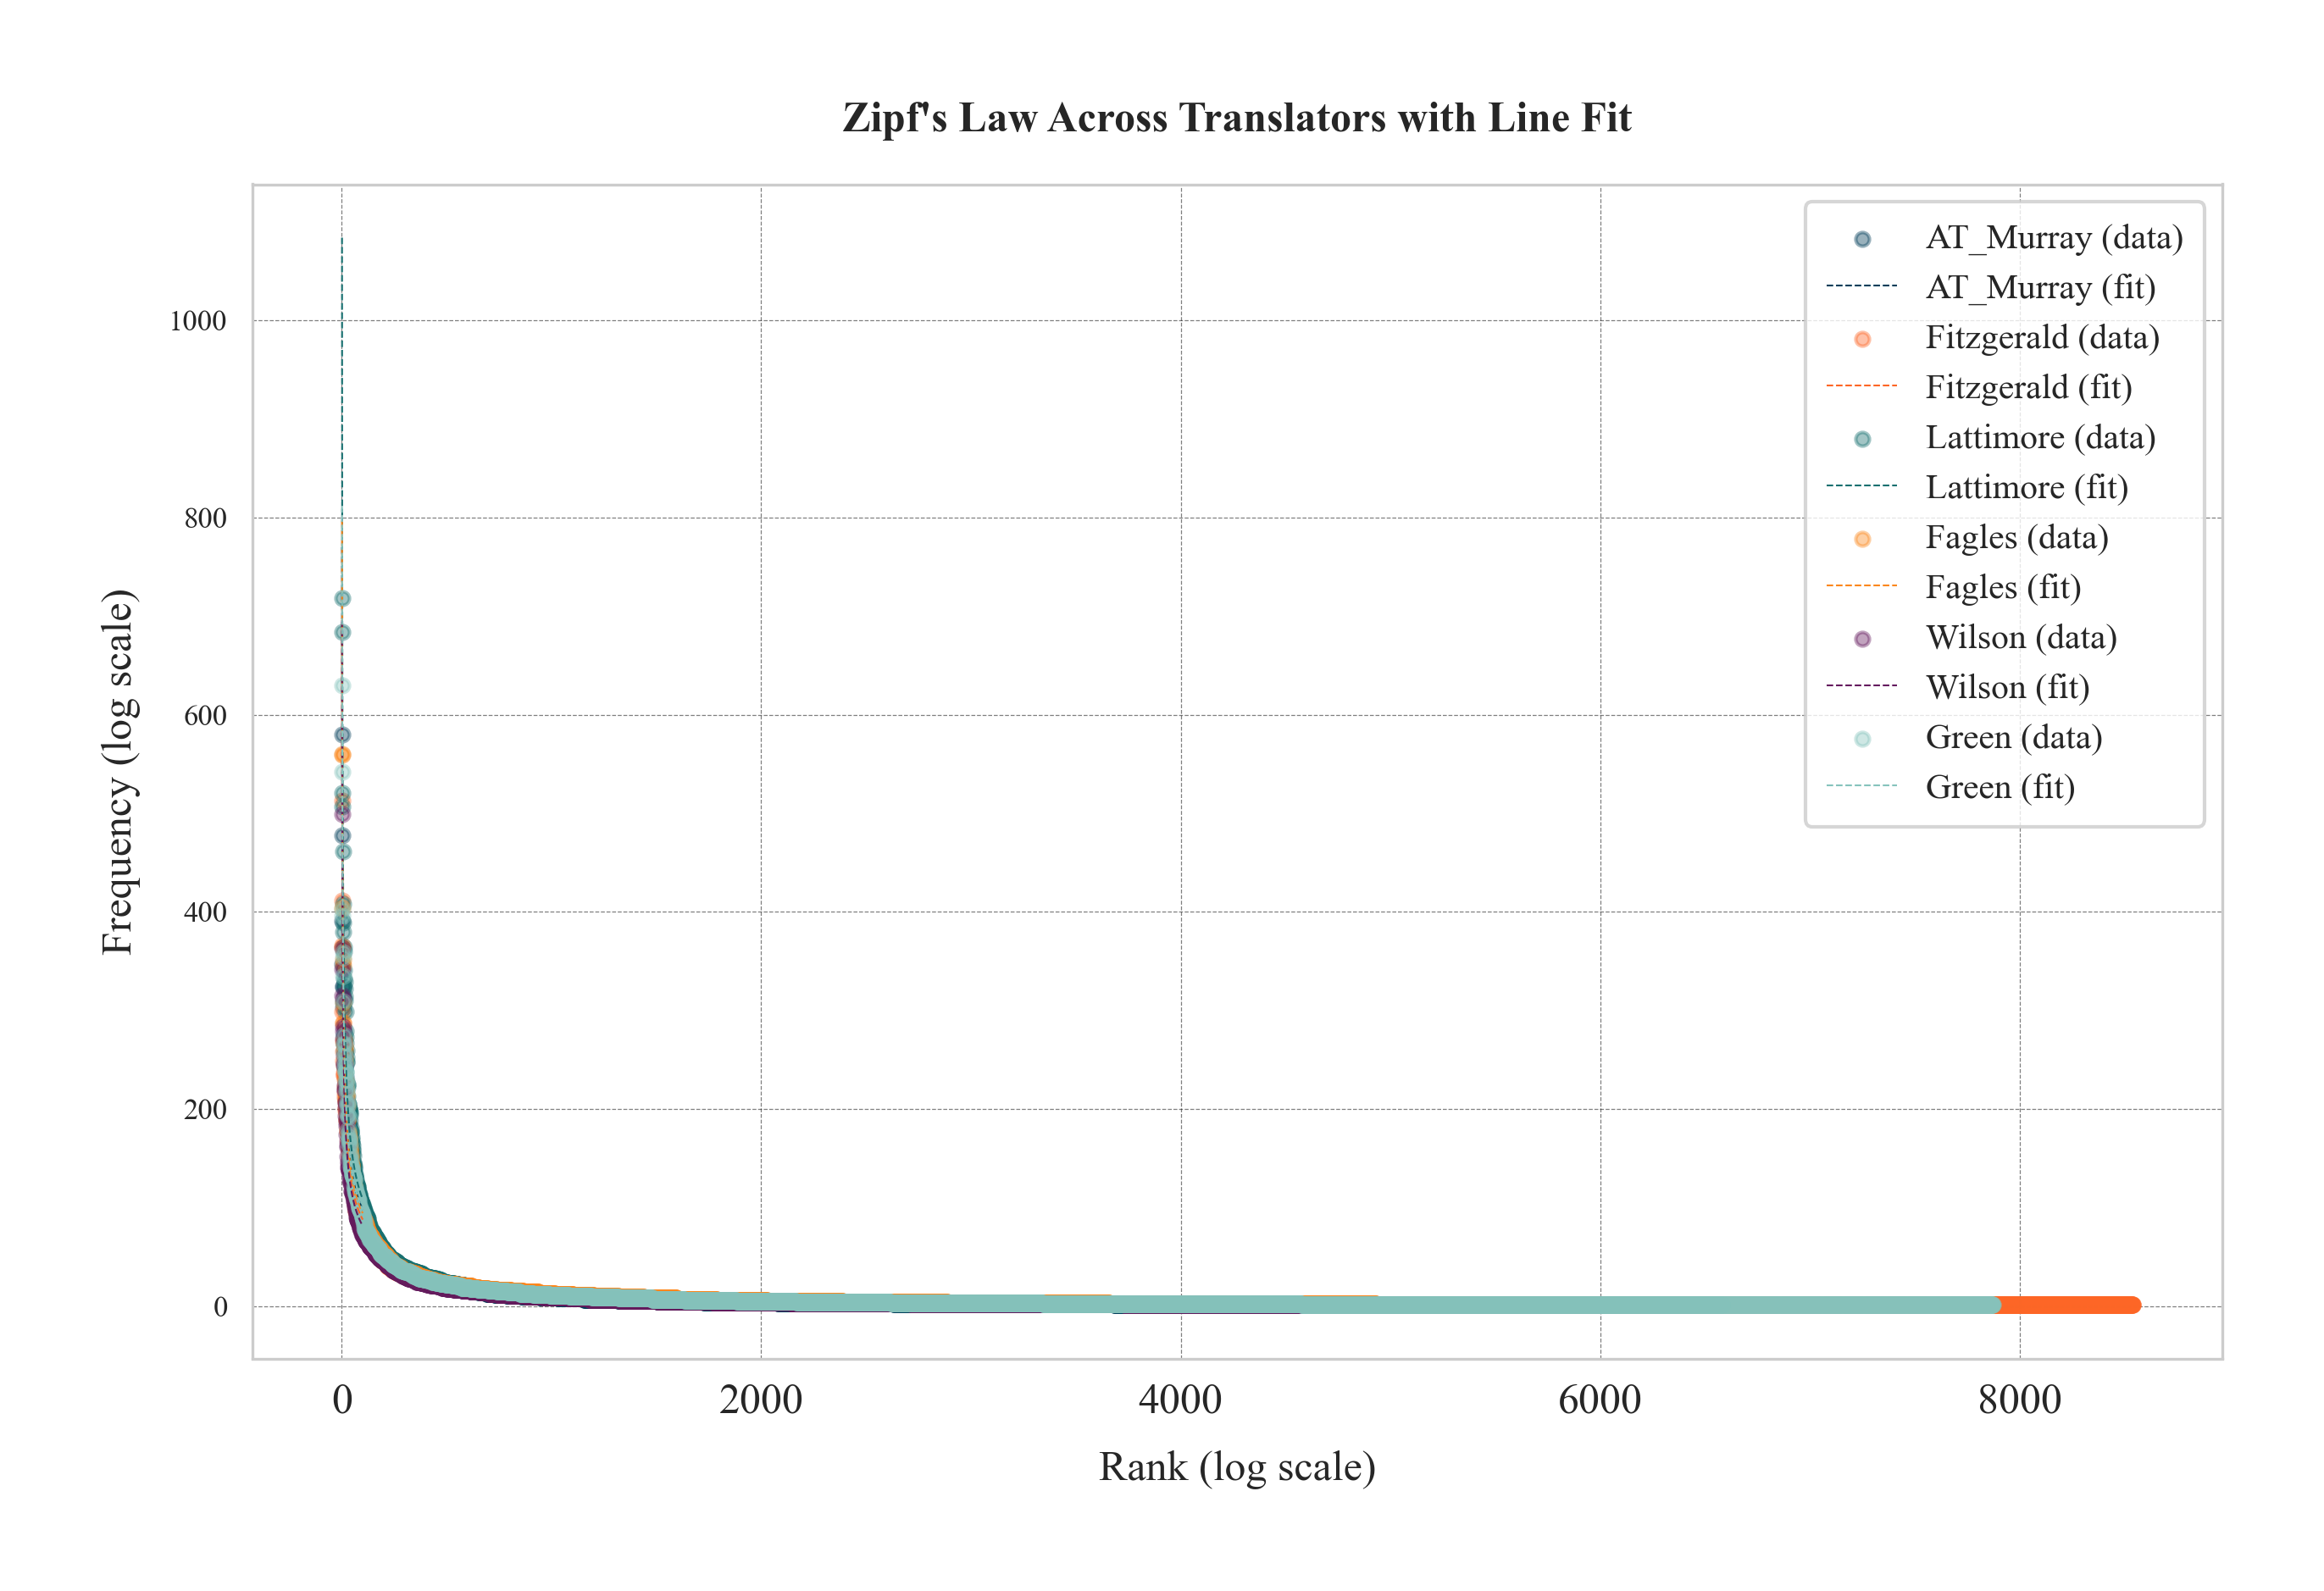

In [102]:
from sklearn.linear_model import LinearRegression
df_zipf_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Step 3: Zipf's Law Plot with Line Fit
def plot_zipfs_law_with_fit(df_zipf_dict):
    plt.figure(figsize=(10, 6))

    for translator, df_zipf in df_zipf_dict.items():
        # Get the top N most frequent words (extreme values)
        top_n = 100  # Adjust this number as needed to capture the most frequent words
        df_zipf_top = df_zipf.head(top_n)

        # Log-transform the rank and frequency for fitting
        x = np.log(df_zipf_top["rank"].values.reshape(-1, 1))  # Rank (log scale)
        y = np.log(df_zipf_top["frequency"].values)  # Frequency (log scale)

        # Fit a linear regression to the log-log data
        model = LinearRegression()
        model.fit(x, y)

        # Predict the line of best fit
        y_pred = model.predict(x)

        # Plot the scatter plot (log-log)
        plt.scatter(df_zipf["rank"], df_zipf["frequency"], label=f"{translator} (data)", alpha=0.4, s=15)

        # Plot the fitted line
        plt.plot(df_zipf_top["rank"], np.exp(y_pred), label=f"{translator} (fit)", linestyle='--', lw=.5)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across Translators with Line Fit")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.3)
    plt.show()

# Call the plotting function
plot_zipfs_law_with_fit(df_zipf_dict)

In [ ]:
# List of translator names and their dataframes
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Get the dataframes from the previously computed df_zipf_dict
df_zipf_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Create empty lists to store results
slopes = []
r_squared = []
p_values = []
std_errs = []
follows_zipf = []

# Perform linear regression in log-log space for each translator
for translator in translators:
    df_zipf = df_zipf_dict[translator]
    
    # Log-transform the rank and frequency
    log_rank = np.log(df_zipf["rank"])
    log_freq = np.log(df_zipf["frequency"])
    #log_rank = np.log(zipf_dfs[i]["rank"] + 1)  # Add a small constant to avoid log(0)
    #log_freq = np.log(zipf_dfs[i]["frequency"] + 1)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
    
    # Store results
    slopes.append(slope)
    r_squared.append(r_value**2)
    p_values.append(p_value)
    std_errs.append(std_err)
    follows_zipf.append(-1.2 < slope < -0.8)
    
    # Display individual results
    print(f"{translator}: Slope = {slope:.2f}, R² = {r_value**2:.3f}, p-value = {p_value:.3g}")
    
    # Check if slope is close to -1 (Zipf's Law predicts ~ -1)
    if -1.2 < slope < -0.8:
        print(f"{translator}'s translation follows Zipf's Law.")
    else:
        print(f"{translator}'s translation deviates from Zipf's Law.")
    print("-" * 50)

# Create a summary dataframe
results_df = pd.DataFrame({
    'Translator': translators,
    'Slope': slopes,
    'R²': r_squared,
    'p-value': p_values,
    'Std Error': std_errs,
    'Follows Zipf\'s Law': follows_zipf
})

print("\nSummary of Zipf's Law Analysis:")
print(results_df)


AT_Murray: Slope = -1.17, R² = 0.964, p-value = 0
AT_Murray's translation follows Zipf's Law.
--------------------------------------------------
Fitzgerald: Slope = -1.08, R² = 0.964, p-value = 0
Fitzgerald's translation follows Zipf's Law.
--------------------------------------------------
Lattimore: Slope = -1.21, R² = 0.958, p-value = 0
Lattimore's translation deviates from Zipf's Law.
--------------------------------------------------
Fagles: Slope = -1.14, R² = 0.954, p-value = 0
Fagles's translation follows Zipf's Law.
--------------------------------------------------
Wilson: Slope = -1.14, R² = 0.960, p-value = 0
Wilson's translation follows Zipf's Law.
--------------------------------------------------
Green: Slope = -1.14, R² = 0.960, p-value = 0
Green's translation follows Zipf's Law.
--------------------------------------------------

Summary of Zipf's Law Analysis:
  Translator   Slope  R²   p-value  Std Error  Follows Zipf's Law
0   AT_Murray -1.17  0.96 0.00     0.00    

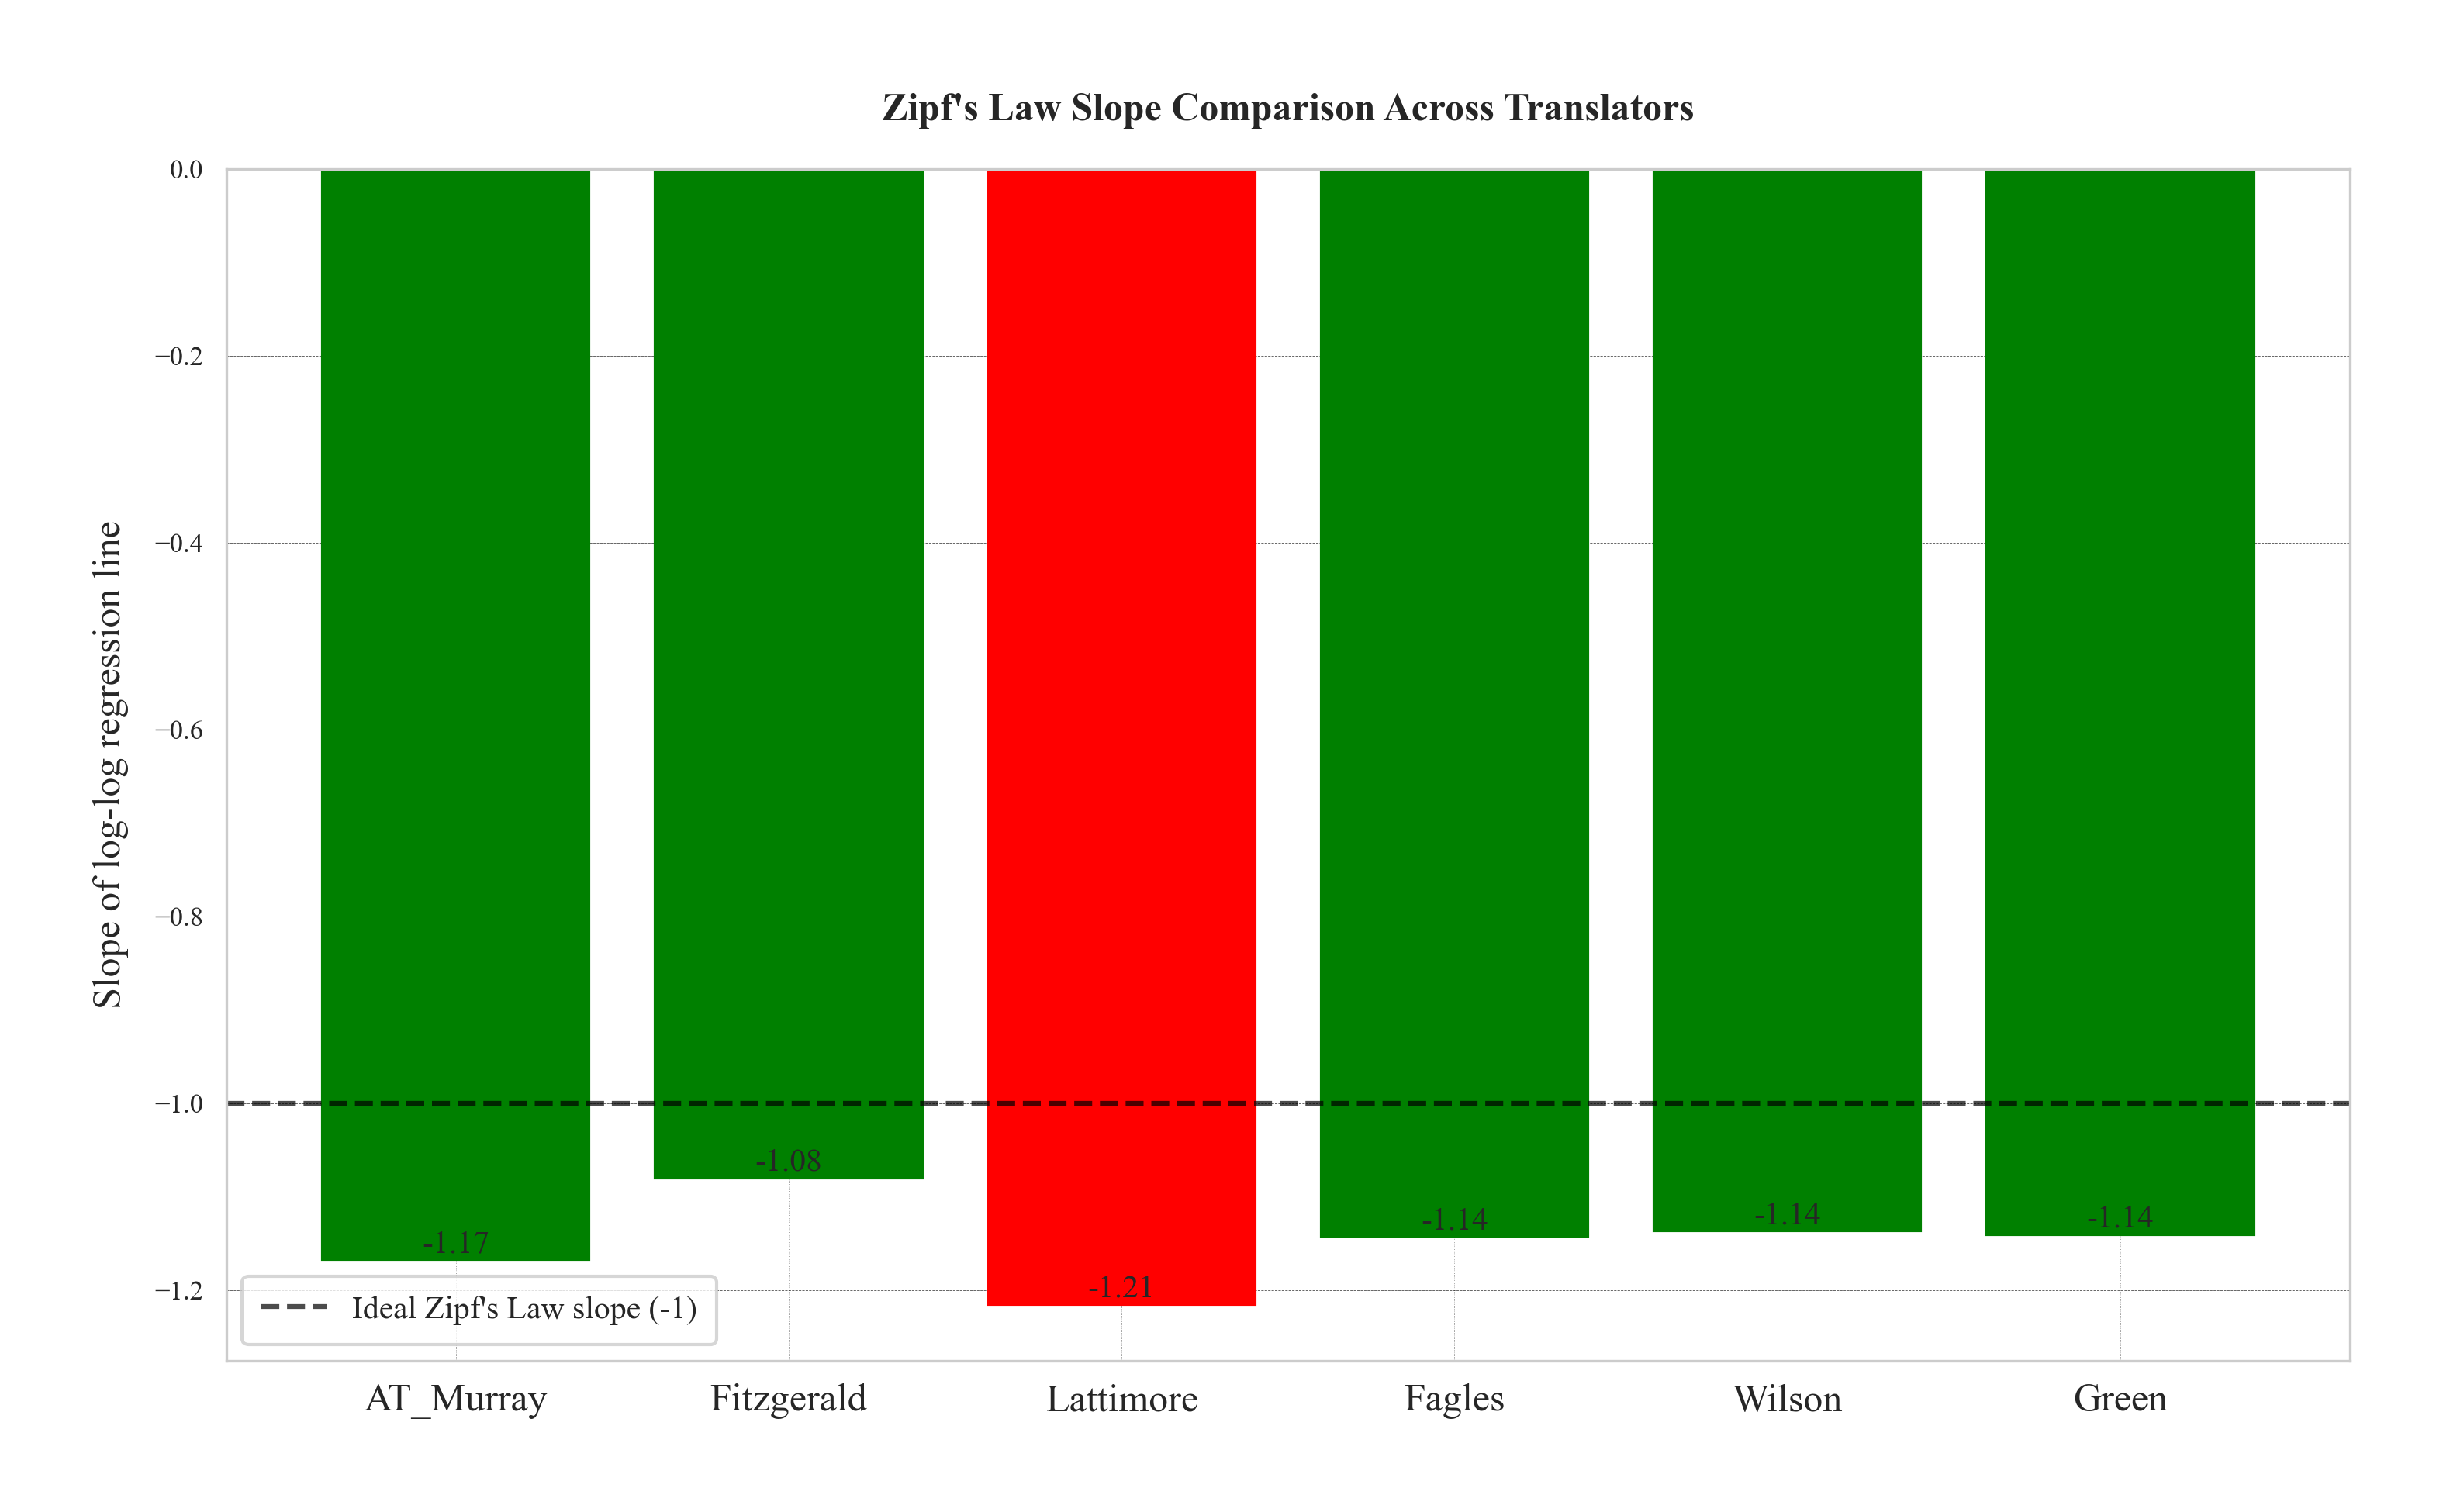

In [117]:
# Create a bar chart to visualize slopes
plt.figure(figsize=(10, 6))
bars = plt.bar(translators, slopes)

# Color the bars based on whether they follow Zipf's Law
for i, follows in enumerate(follows_zipf):
    bars[i].set_color('green' if follows else 'red')

# Add a horizontal line at -1 (ideal Zipf's Law slope)
plt.axhline(y=-1, color='black', linestyle='--', alpha=0.7, label="Ideal Zipf's Law slope (-1)")

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{slopes[i]:.2f}',
            ha='center', va='bottom' if height < 0 else 'top', 
            rotation=0)

plt.title("Zipf's Law Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [118]:
# Statistical comparison of slopes (using confidence intervals)
print("\nStatistical comparison of slopes:")
for i in range(len(translators)):
    for j in range(i+1, len(translators)):
        # Calculate standard error of the difference between slopes
        se_diff = np.sqrt(std_errs[i]**2 + std_errs[j]**2)
        
        # Calculate t-statistic
        t_stat = (slopes[i] - slopes[j]) / se_diff
        
        # Calculate degrees of freedom (approximation)
        d_freedom = len(df_zipf_dict[translators[i]]["rank"]) + len(df_zipf_dict[translators[j]]["rank"]) - 4
        
        # Calculate p-value
        from scipy.stats import t
        p_val = 2 * (1 - t.cdf(abs(t_stat), d_freedom))
        
        print(f"{translators[i]} vs {translators[j]}: Slope diff = {slopes[i]-slopes[j]:.3f}, p = {p_val:.4f}")
        if p_val < 0.05:
            print("   -> Statistically significant difference in slopes")
        else:
            print("   -> No statistically significant difference in slopes")


Statistical comparison of slopes:
AT_Murray vs Fitzgerald: Slope diff = -0.087, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Lattimore: Slope diff = 0.048, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Fagles: Slope diff = -0.025, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Wilson: Slope diff = -0.031, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Green: Slope diff = -0.027, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Lattimore: Slope diff = 0.135, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Fagles: Slope diff = 0.063, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Wilson: Slope diff = 0.057, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Green: Slope diff = 0.061, p = 0.0000
   -> Statistically significant difference in slopes
Latt

One-Way ANOVA (Single Test for All Translators)

The ANOVA test is used when you want to compare the means of more than two groups—in this case, the slopes of the different translators. This will tell you if there are any significant differences between the slopes across all translators.


In [123]:
# Slopes for each translator
slopes = results_df["Slope"]
type(slopes)

pandas.core.series.Series

In [124]:
import numpy as np
import scipy.stats as stats

# Your Zipf's law slopes data
slopes = dict(zip(results_df['Translator'], results_df['Slope']))
# Prepare data for ANOVA
# Convert dictionary to a list of lists
slope_groups = [np.array([slope]) for slope in slopes.values()]

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*slope_groups)

print(f"ANOVA F-statistic: {f_stat:.3f}, P-value: {p_value:.5f}")

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in Zipf's Law slopes among the translators.")
else:
    print("No statistically significant difference in Zipf's Law slopes among the translators.")

ANOVA F-statistic: nan, P-value: nan
No statistically significant difference in Zipf's Law slopes among the translators.


/Users/debr/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4141: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


In [125]:
print(df_zipf_at_murray["rank"].nunique())  # Check the number of unique ranks
print(df_zipf_at_murray["frequency"].nunique())  # Check the number of unique frequencies

NameError: name 'df_zipf_at_murray' is not defined